In [119]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [77]:
# Load Data
print("Loading data...")
demographics = pd.read_csv('data/demographics.csv')
current_commitments = pd.read_csv('data/current_commitments.csv')
prior_commitments = pd.read_csv('data/prior_commitments.csv')

print(f"\nDemographics shape: {demographics.shape}")
print(f"Current commitments shape: {current_commitments.shape}")
print(f"Prior commitments shape: {prior_commitments.shape}")

Loading data...


/var/folders/qq/2xq_hbb10j75t18jqwpwnfzh0000gn/T/ipykernel_7942/3625507257.py:4: DtypeWarning: Columns (7,22,23,24,25,26,27,28,29,30,31,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  current_commitments = pd.read_csv('data/current_commitments.csv')



Demographics shape: (95476, 13)
Current commitments shape: (369125, 34)
Prior commitments shape: (191436, 13)


# Part 1: Understanding the Basics

## 1.1 View First 5 rows

In [78]:
demographics.head()

,CDCNo,Ethnicity,Controlling Offense,Description,Offense Begin Date,Offense End Date,Controlling Case Number,Controlling Case Sentencing County,Sentence Type,Aggregate Sentence in Months,Offense Category,EPRD/MEPD Month and Year,Current Location
0,2cf2a233c4,Black,VC10851(a),Vehicle Theft,2022-12-07,2022-12-07,FVI22003547,San Bernardino,Second Striker,32,Property Crimes,APR24,Central California Women's Facility
1,5a72696541,White,PC187 2nd,Murder 2nd,2012-09-18,2012-09-18,12F06402,Sacramento,Life with Parole,360,Crimes Against Persons,NOV33,Central California Women's Facility
2,7d608b6a4c,White,PC187 2nd,Murder 2nd,2010-05-18,2010-05-18,CM032513,Butte,Life with Parole,300,Crimes Against Persons,SEP28,Central California Women's Facility
3,39c1bc8c2f,Other,PC459,Burglary 1st,1998-01-20,1998-01-20,CM010387,Butte,Third Striker,348,Property Crimes,NOV22,California Institution for Women
4,220f2cdfc5,Black,PC187,Murder 1st,2017-03-21,2017-03-21,BA455966,Los Angeles,Life with Parole,312,Crimes Against Persons,MAY35,California Institution for Women


In [79]:
current_commitments.head()

,CDCNo,Sentencing County,Case Number,Sentence From Abstract of Judgement,Offense,Offense Description,Offense Category,In-prison,Offense Begin Date,Offense End Date,...,Off_Enh7,Off_Enh_Desc7,Off_Enh8,Off_Enh_Desc8,Off_Enh9,Off_Enh_Desc9,Off_Enh10,Off_Enh_Desc10,Off_Enh11,Off_Enh_Desc11
0,2cf2a233c4,San Bernardino,FVI22003547,2 Years 8 Months,VC10851(a),Vehicle Theft,Property Crimes,NaN,2022-12-07,2022-12-07 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5a72696541,Sacramento,12F06402,Life with Parole,PC191.5(c)(2),Vehicular Manslaughter While Intoxicated,Crimes Against Persons,NaN,2012-09-18,2012-09-18 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5a72696541,Sacramento,12F06402,Life with Parole,PC187 2nd,Murder 2nd,Crimes Against Persons,NaN,2012-09-18,2012-09-18 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7d608b6a4c,Butte,CM032513,Life with Parole,PC187 2nd,Murder 2nd,Crimes Against Persons,NaN,2010-05-18,2010-05-18 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,39c1bc8c2f,San Bernardino,FWV1404908,1 Years 4 Months,PC4573.8,Possession Paraphernalia/Drugs/Alcohol in Jail...,Drug Crimes,In-Prison,2014-09-12,2014-09-12 00:00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
prior_commitments.head()

,CDCNo,Sentencing County,Case Number,Sentence From Abstract of Judgement,Offense,Offense Description,Offense Category,In-prison,Offense Begin Date,Offense End Date,Offense Time with Enhancement,Relationship,Release Date
0,2cf2a233c4,Los Angeles,KA048775,1 Years 4 Months,HS11350(a),Possess Controlled Substance,Drug Crimes,NaN,2000-06-06,2000-06-06,1 Year 4 Months,Concurrent,2001-03-08
1,2cf2a233c4,Los Angeles,KA035079,2 Years 8 Months,PC459 2nd,Burglary 2nd,Property Crimes,NaN,1996-11-25,1996-11-25,2 Years 0 Months,Initial,1998-08-14
2,2cf2a233c4,Los Angeles,KA020374,3 Years,HS11352(a),Transport/Sell Controlled Substance,Drug Crimes,NaN,1993-12-10,1993-12-10,3 Years 0 Months,Initial,1995-09-18
3,2cf2a233c4,San Bernardino,FSB1001777,4 Years,PC667.5(b),Prior Prison Term/Non Violent new offense is a...,Case Enhancement,NaN,NaN,NaN,1 Year,Consecutive,NaN
4,2cf2a233c4,Los Angeles,KA035079,2 Years 8 Months,PC666,Petty Theft With Prior,Property Crimes,NaN,1996-12-17,1996-12-17,2 Years 0 Months,Concurrent,1998-08-14


## 1.2 Look At Missing Values

In [81]:
demographics.isna().sum()

CDCNo                                     0
Ethnicity                                 0
Controlling Offense                       1
Description                               1
Offense Begin Date                        1
Offense End Date                          1
Controlling Case Number               25356
Controlling Case Sentencing County        0
Sentence Type                             0
Aggregate Sentence in Months              0
Offense Category                          0
EPRD/MEPD Month and Year                  1
Current Location                          0
dtype: int64

In [82]:
current_commitments.isna().sum()

CDCNo                                       0
Sentencing County                           1
Case Number                            133276
Sentence From Abstract of Judgement        61
Offense                                     1
Offense Description                         1
Offense Category                            0
In-prison                              352794
Offense Begin Date                      37455
Offense End Date                        37455
Offense Time with Enhancement               0
Relationship                                1
Off_Enh1                               273164
Off_Enh_Desc1                          273164
Off_Enh2                               347518
Off_Enh_Desc2                          347518
Off_Enh3                               364226
Off_Enh_Desc3                          364226
Off_Enh4                               367665
Off_Enh_Desc4                          367665
Off_Enh5                               368715
Off_Enh_Desc5                     

In [83]:
prior_commitments.isna().sum()

CDCNo                                       0
Sentencing County                           1
Case Number                             35880
Sentence From Abstract of Judgement      1373
Offense                                     1
Offense Description                         1
Offense Category                            0
In-prison                              188276
Offense Begin Date                      22188
Offense End Date                        22188
Offense Time with Enhancement               0
Relationship                                1
Release Date                            22083
dtype: int64

## 1.3 Look at Unique Values

In [84]:
for col in demographics.columns:
    if demographics[col].nunique() < 1000:
        print(f"Number of unique values in {col}: {demographics[col].nunique()}")

Number of unique values in Ethnicity: 28
Number of unique values in Controlling Offense: 483
Number of unique values in Description: 528
Number of unique values in Controlling Case Sentencing County: 57
Number of unique values in Sentence Type: 7
Number of unique values in Offense Category: 4
Number of unique values in Current Location: 36


In [85]:
current_commitments_columns = ["Sentencing County", "Sentence From Abstract of Judgement", "Offense", "Offense Description", "Offense Category", "Offense Time with Enhancement", "Relationship"]

for col in current_commitments_columns:
    print(f"Number of unique values in {col}: {current_commitments[col].nunique()}")

Number of unique values in Sentencing County: 57
Number of unique values in Sentence From Abstract of Judgement: 506
Number of unique values in Offense: 835
Number of unique values in Offense Description: 890
Number of unique values in Offense Category: 5
Number of unique values in Offense Time with Enhancement: 324
Number of unique values in Relationship: 4


In [86]:
prior_commitments_columns = ["Sentencing County", "Sentence From Abstract of Judgement", "Offense", "Offense Description", "Offense Category", "Offense Time with Enhancement", "Relationship"]

for col in prior_commitments_columns:
    print(f"Number of unique values in {col}: {prior_commitments[col].nunique()}")

Number of unique values in Sentencing County: 59
Number of unique values in Sentence From Abstract of Judgement: 182
Number of unique values in Offense: 796
Number of unique values in Offense Description: 845
Number of unique values in Offense Category: 5
Number of unique values in Offense Time with Enhancement: 133
Number of unique values in Relationship: 4


## 1.4 Look at Data Types

In [87]:
demographics.dtypes

CDCNo                                 object
Ethnicity                             object
Controlling Offense                   object
Description                           object
Offense Begin Date                    object
Offense End Date                      object
Controlling Case Number               object
Controlling Case Sentencing County    object
Sentence Type                         object
Aggregate Sentence in Months           int64
Offense Category                      object
EPRD/MEPD Month and Year              object
Current Location                      object
dtype: object

In [88]:
current_commitments.dtypes

CDCNo                                  object
Sentencing County                      object
Case Number                            object
Sentence From Abstract of Judgement    object
Offense                                object
Offense Description                    object
Offense Category                       object
In-prison                              object
Offense Begin Date                     object
Offense End Date                       object
Offense Time with Enhancement          object
Relationship                           object
Off_Enh1                               object
Off_Enh_Desc1                          object
Off_Enh2                               object
Off_Enh_Desc2                          object
Off_Enh3                               object
Off_Enh_Desc3                          object
Off_Enh4                               object
Off_Enh_Desc4                          object
Off_Enh5                               object
Off_Enh_Desc5                     

In [89]:
prior_commitments.dtypes

CDCNo                                  object
Sentencing County                      object
Case Number                            object
Sentence From Abstract of Judgement    object
Offense                                object
Offense Description                    object
Offense Category                       object
In-prison                              object
Offense Begin Date                     object
Offense End Date                       object
Offense Time with Enhancement          object
Relationship                           object
Release Date                           object
dtype: object

# Part 2: Data Visualization 

## 2.1 Histograms (To Understand Distributions)

### 2.1.1 Histograms For Demographics

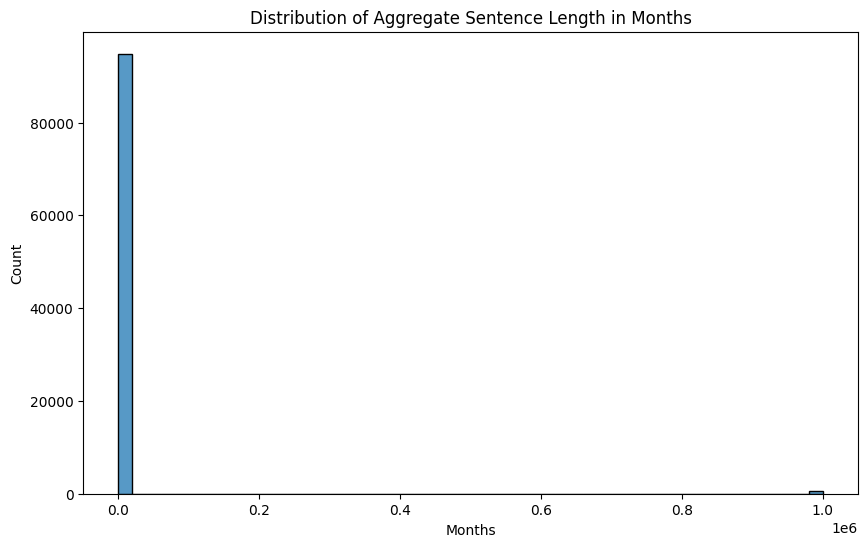

In [90]:
# Distribution of Aggregate Sentence in Months
plt.figure(figsize=(10, 6))
sns.histplot(demographics['Aggregate Sentence in Months'], bins=50)
plt.title('Distribution of Aggregate Sentence Length in Months')
plt.xlabel('Months')
plt.ylabel('Count')
plt.show()

In [91]:
# Check how many values don't make sense
len(demographics[demographics['Aggregate Sentence in Months'] > 2000])

7209

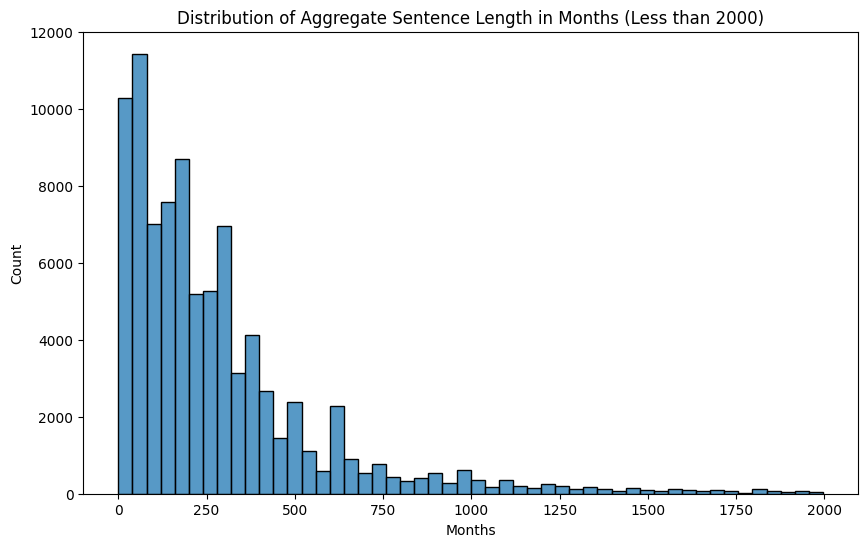

In [92]:
# Filter out both 1000000 and 100000 months
filtered_data = demographics[
    (demographics['Aggregate Sentence in Months'] < 2000)
]

# Visualize Sentence Length Distribution
plt.figure(figsize=(10, 6))
sns.histplot(filtered_data['Aggregate Sentence in Months'], bins=50)
plt.title('Distribution of Aggregate Sentence Length in Months (Less than 2000)')
plt.xlabel('Months')
plt.ylabel('Count')
plt.show()

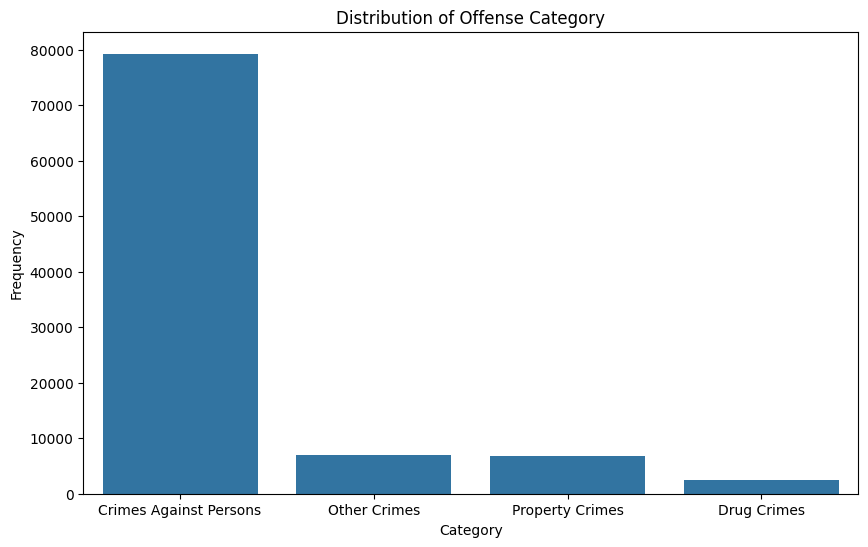

In [93]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Offense Category', 
    y='count', 
    data=demographics['Offense Category'].value_counts().reset_index()
)
plt.title('Distribution of Offense Category')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

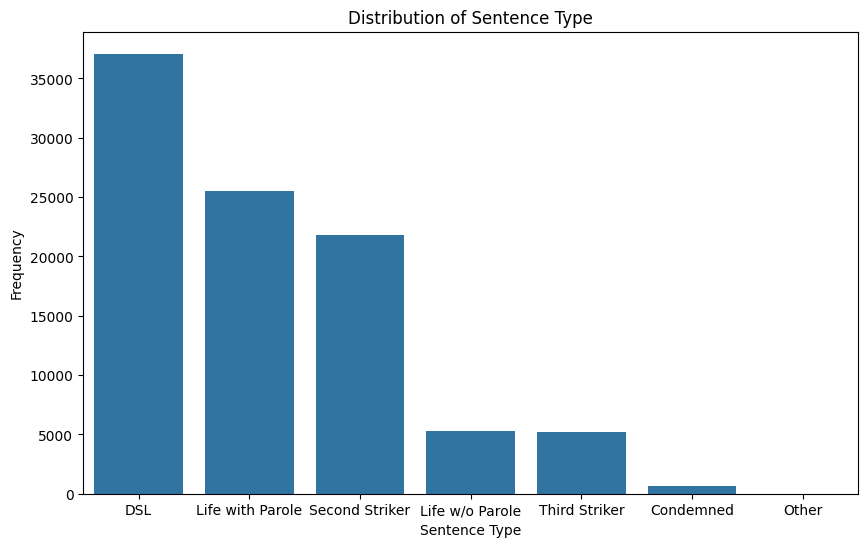

In [94]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Sentence Type', 
    y='count', 
    data=demographics['Sentence Type'].value_counts().reset_index()
)
plt.title('Distribution of Sentence Type')
plt.xlabel('Sentence Type')
plt.ylabel('Frequency')
plt.show()

### 2.1.2 Histograms for Current Commitments

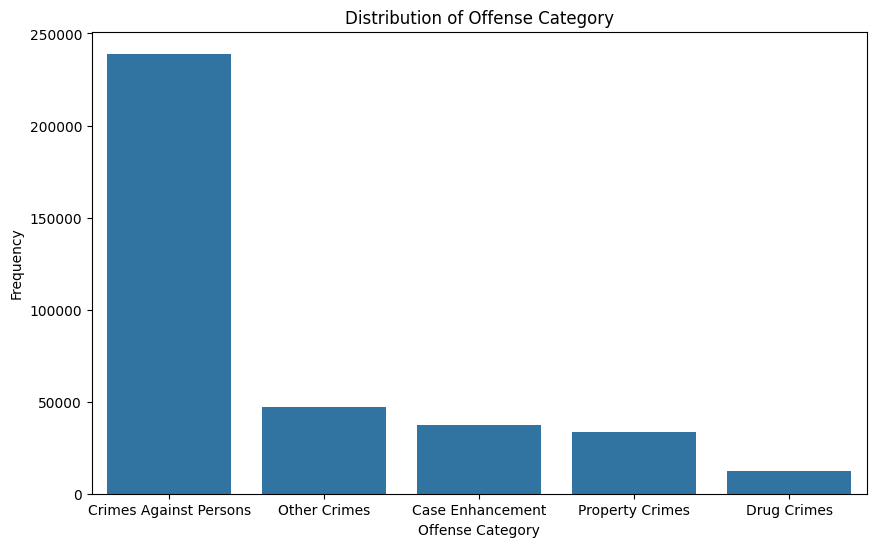

In [95]:
# Offense Category
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Offense Category', 
    y='count', 
    data=current_commitments['Offense Category'].value_counts().reset_index()
)
plt.title('Distribution of Offense Category')
plt.xlabel('Offense Category')
plt.ylabel('Frequency')
plt.show()


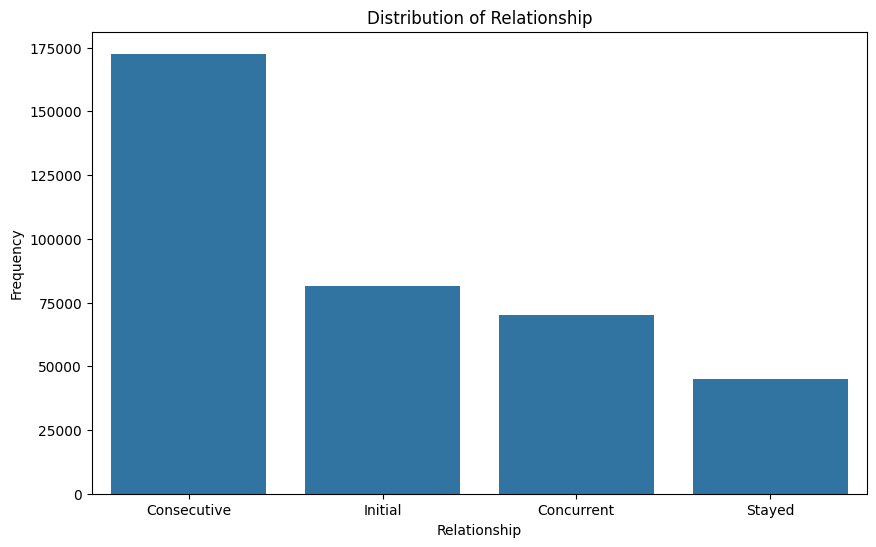

In [96]:
# Relationship
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Relationship', 
    y='count', 
    data=current_commitments['Relationship'].value_counts().reset_index()
)
plt.title('Distribution of Relationship')
plt.xlabel('Relationship')
plt.ylabel('Frequency')
plt.show()

# 3 Data Cleaning

## 3.1 Dropping Unecessary Columns

In [97]:
# Demographics
demographics = demographics.drop(columns=[
    'Controlling Case Number',
    'Current Location',
    'Aggregate Sentence in Months'
])

# Current Commitments
current_commitments = current_commitments.drop(columns=[
    'Case Number',
    'Sentence From Abstract of Judgement',
    'Offense',
    'In-prison'
] + [col for col in current_commitments.filter(regex='Enh').columns if col != 'Offense Time with Enhancement'])

# Prior Commitments
prior_commitments = prior_commitments.drop(columns=[
    'Case Number',
    'Sentence From Abstract of Judgement',
    'Offense',
    'In-prison'
])

## 3.2 Converting to Correct Data Types

In [98]:
# Demographics: Convert to datetime
demographics['Offense Begin Date'] = pd.to_datetime(demographics['Offense Begin Date'])
demographics['Offense End Date'] = pd.to_datetime(demographics['Offense End Date'])
demographics['EPRD/MEPD Month and Year'] = pd.to_datetime(demographics['EPRD/MEPD Month and Year'], format='%b%y')

In [106]:
sorted(list(set(current_commitments['Offense Time with Enhancement'])), reverse=True)

['Years Months',
 'Stayed',
 'Life without Possibility of Parole',
 'Condemned',
 '95 Years 0 Months-to-Life',
 '93 Years 0 Months-to-Life',
 '90 Years 0 Months-to-Life',
 '90 Years',
 '9 Years 8 Months-to-Life',
 '9 Years 8 Months',
 '9 Years 6 Months',
 '9 Years 4 Months-to-Life',
 '9 Years 4 Months',
 '9 Years 0 Months-to-Life',
 '9 Years 0 Months',
 '87 Years 0 Months-to-Life',
 '86 Years 0 Months',
 '85 Years 0 Months-to-Life',
 '84 Years 0 Months-to-Life',
 '83 Years 0 Months-to-Life',
 '82 Years 0 Months-to-Life',
 '81 Years 0 Months-to-Life',
 '80 Years 0 Months-to-Life',
 '8 Years 8 Months-to-Life',
 '8 Years 8 Months',
 '8 Years 6 Months',
 '8 Years 4 Months-to-Life',
 '8 Years 4 Months',
 '8 Years 3 Months-to-Life',
 '8 Years 0 Months-to-Life',
 '8 Years 0 Months',
 '8 Months-to-Life',
 '8 Months',
 '79 Years 0 Months-to-Life',
 '78 Years 0 Months-to-Life',
 '76 Years 0 Months-to-Life',
 '75 Years 0 Months-to-Life',
 '75 Years',
 '73 Years 0 Months-to-Life',
 '72 Years 0 Mon

In [108]:
# Convert "X Years Y Months" to months (numeric)
def parse_sentence(sentence):
    # Handle None or empty strings
    if not sentence or pd.isna(sentence):
        return 0
    
    # Convert to string in case it's not already
    sentence = str(sentence)
    
    # Handle special cases
    if sentence == "Life without Possibility of Parole" or sentence == "Condemned":
        return float('inf')
    if sentence == "Stayed":
        return 0
    
    # Remove "-to-Life" suffix if present
    if "-to-Life" in sentence:
        sentence = sentence.replace("-to-Life", "")
    
    # Handle 1E3
    if sentence.startswith("1E3"):
        return 1000 * 12 + 3 
    
    total_months = 0
    
    # Extract years
    if "Years" in sentence or "Year" in sentence:
        years_part = sentence.split("Years" if "Years" in sentence else "Year")[0].strip()
        if years_part:  # Check if years_part is not empty
            years = float(years_part)
            total_months += years * 12
    
    # Extract months
    if "Months" in sentence or "Month" in sentence:
        # Check if there are years specified
        if "Years" in sentence or "Year" in sentence:
            # Get the part between "Years"/"Year" and "Months"/"Month"
            months_part = sentence.split("Years" if "Years" in sentence else "Year")[1]
            months_part = months_part.split("Months" if "Months" in sentence else "Month")[0].strip()
            # Remove any leading characters that aren't part of the number
            if months_part.startswith(" "):
                months_part = months_part[1:]
            if months_part:  # Check if months_part is not empty
                months = float(months_part)
                total_months += months
        else:
            # No years specified, only months
            months_part = sentence.split("Months" if "Months" in sentence else "Month")[0].strip()
            if months_part:  # Check if months_part is not empty
                months = float(months_part)
                total_months += months
    
    return total_months

current_commitments['Offense Time with Enhancement (Months)'] = current_commitments['Offense Time with Enhancement'].apply(parse_sentence)

In [116]:
sorted(list(set(current_commitments['Offense Time with Enhancement (Months)'])), reverse=True)

[inf,
 12003.0,
 1440.0,
 1380.0,
 1212.0,
 1200.0,
 1140.0,
 1116.0,
 1080.0,
 1044.0,
 1032.0,
 1020.0,
 1008.0,
 996.0,
 984.0,
 972.0,
 960.0,
 948.0,
 936.0,
 912.0,
 900.0,
 876.0,
 864.0,
 852.0,
 840.0,
 828.0,
 816.0,
 804.0,
 792.0,
 780.0,
 774.0,
 768.0,
 756.0,
 744.0,
 732.0,
 720.0,
 708.0,
 696.0,
 684.0,
 672.0,
 660.0,
 648.0,
 636.0,
 628.0,
 624.0,
 616.0,
 612.0,
 606.0,
 600.0,
 594.0,
 588.0,
 576.0,
 564.0,
 552.0,
 540.0,
 533.0,
 528.0,
 516.0,
 504.0,
 492.0,
 484.0,
 480.0,
 474.0,
 468.0,
 464.0,
 462.0,
 456.0,
 448.0,
 444.0,
 436.0,
 432.0,
 420.0,
 416.0,
 414.0,
 412.0,
 408.0,
 400.0,
 396.0,
 392.0,
 388.0,
 384.0,
 380.0,
 376.0,
 372.0,
 368.0,
 366.0,
 364.0,
 360.0,
 356.0,
 354.0,
 352.0,
 348.0,
 344.0,
 342.0,
 340.0,
 336.0,
 332.0,
 330.0,
 328.0,
 324.0,
 320.0,
 318.0,
 316.0,
 312.0,
 308.0,
 306.0,
 304.0,
 302.0,
 300.0,
 296.0,
 294.0,
 288.0,
 280.0,
 276.0,
 272.0,
 270.0,
 268.0,
 264.0,
 260.0,
 258.0,
 256.0,
 252.0,
 248.0,
 246.

In [118]:
current_commitments[current_commitments['Offense Time with Enhancement (Months)'] == 12003.0]

,CDCNo,Sentencing County,Offense Description,Offense Category,Offense Begin Date,Offense End Date,Offense Time with Enhancement,Relationship,Offense Time with Enhancement (Months)
19167,e53d24d5b8,Stanislaus,Murder 1st (LWO),Crimes Against Persons,1992-05-06,1992-05-06 00:00:00,1E3 Years 3 Months-to-Life,Consecutive,12003.0
30236,3a813014fe,Los Angeles,Murder 1st (Death),Crimes Against Persons,1989-10-30,1989-10-30 00:00:00,1E3 Years 3 Months-to-Life,Concurrent,12003.0
56963,d125af358f,Riverside,Murder 1st (Death),Crimes Against Persons,1989-01-10,1989-01-10 00:00:00,1E3 Years 3 Months-to-Life,Consecutive,12003.0
107511,bafbb8aa08,Santa Clara,Murder 1st (LWO),Crimes Against Persons,1979-12-15,1979-12-15 00:00:00,1E3 Years 3 Months-to-Life,Concurrent,12003.0
221498,cc1d45342d,Los Angeles,Murder 1st (LWO),Crimes Against Persons,1998-11-04,1998-11-04 00:00:00,1E3 Years 3 Months-to-Life,Consecutive,12003.0


In [109]:
# Prior commitments
# Convert dates
prior_commitments['Offense Begin Date'] = pd.to_datetime(prior_commitments['Offense Begin Date'])
prior_commitments['Offense End Date'] = pd.to_datetime(prior_commitments['Offense End Date'])
prior_commitments['Release Date'] = pd.to_datetime(prior_commitments['Release Date'])

# Convert sentence durations to months
prior_commitments['Offense Time with Enhancement (Months)'] = prior_commitments['Offense Time with Enhancement'].apply(parse_sentence)

# 3.3 Merging Datasets

In [120]:
# Merge demographics and current commitments on CDCNo
preprocessed_dir = 'data/preprocessed'
os.makedirs(preprocessed_dir, exist_ok=True)

# Merge the data (using your preferred merge approach)
merged_data = pd.merge(
    demographics,
    current_commitments,
    on='CDCNo',
    how='left',
    suffixes=('_demo', '_current')
)

# Define the output path
output_path = os.path.join(preprocessed_dir, 'merged_inmate_data.csv')

# Save to CSV
merged_data.to_csv(output_path, index=False)

print(f"Merged data successfully saved to: {output_path}")
print(f"File contains {len(merged_data)} records with {len(merged_data.columns)} columns")


Merged data successfully saved to: data/preprocessed/merged_inmate_data.csv
File contains 369125 records with 18 columns
